# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [M. Ardifa Rizqi Ramadhan]
- **Email:** [ardifasgt17@gmail.com]
- **ID Dicoding:** [ardifarr]

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penjualan dan revenue perusahaan pada pertengahan 2016 hingga pertengahan 2018?
- Bagaimana demografi customer yang dimiliki?
- Kategori produk apa yang paling banyak diminati?

## Import Semua Packages/Library yang Digunakan

In [63]:
import os
import zipfile
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
local_zip = '/content/drive/MyDrive/Coding Camp DS/Submission Tech/Belajar Fundamental Analisis Data/E-commerce-public-dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()
os.listdir()

['.config',
 '.ipynb_checkpoints',
 'E-Commerce Public Dataset',
 'drive',
 'sample_data']

In [66]:
dir_path = '/content/E-Commerce Public Dataset'
os.listdir(dir_path)

['sellers_dataset.csv',
 'orders_dataset.csv',
 'order_payments_dataset.csv',
 'product_category_name_translation.csv',
 'customers_dataset.csv',
 'order_items_dataset.csv',
 'order_reviews_dataset.csv',
 'geolocation_dataset.csv',
 'New Text Document.txt',
 'products_dataset.csv']

In [67]:
# Customers Atribute
customers_df = pd.read_csv("/content/E-Commerce Public Dataset/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [68]:
# Product Atribute
products_df = pd.read_csv("/content/E-Commerce Public Dataset/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [69]:
# Product Category Atribute
products_category_df = pd.read_csv("/content/E-Commerce Public Dataset/product_category_name_translation.csv")
products_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [70]:
# Orders Atribute
orders_df = pd.read_csv("/content/E-Commerce Public Dataset/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [71]:
# Order Item Atribute
order_items_df = pd.read_csv("/content/E-Commerce Public Dataset/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Memuat tabel Customers
- Memuat tabel Products
- Memuat tabel Orders
- Memuat tabel Order Items

### Assessing Data

#### Review Data Customers

In [72]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [73]:
customers_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [74]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [75]:
print('Jumlah duplikasi data Customers:', customers_df.duplicated().sum())

Jumlah duplikasi data Customers: 0


Berdasarkan Review pada data Customers, tidak terdapat missing value dan data duplikasi yang menunjukkan bahwa data tersebut telah bersih.

#### Review Data Products

In [76]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [77]:
products_df.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [78]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [79]:
print('Jumlah duplikasi data Products:', products_df.duplicated().sum())

Jumlah duplikasi data Products: 0


Berdasarkan review data Products, ditemukan missing value pada kolom **product_category_name**, **product_name_lenght**, **product_description_lenght**, **product_photos_qty**, **product_weight_g**, **product_length_cm**, **product_height_cm**, **product_width_cm**.

#### Review Data Product Category

In [80]:
products_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [81]:
products_category_df.describe(include='all')

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [82]:
products_category_df.isnull().sum()

,0
product_category_name,0
product_category_name_english,0


In [83]:
print('Jumlah duplikasi data Product Category:', products_category_df.duplicated().sum())

Jumlah duplikasi data Product Category: 0


Berdasarkan review data Product Category, tidak terdapat missing value dan data duplikasi yang menunjukkan bahwa data tersebut telah bersih.

#### Review Data Order

In [84]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [85]:
orders_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [86]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [87]:
print('Jumlah duplikasi data Order:', orders_df.duplicated().sum())

Jumlah duplikasi data Order: 0


Berdasarkan Review data Orders, ditemukan:
*   tipe data yang tidak sesuai pada kolom order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
*   Missing value pada order_approved_at, order_delivered_carrier_date, order_delivered_customer_date.



#### Review Data Order Item

In [88]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [89]:
order_items_df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [90]:
order_items_df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [91]:
print('Jumlah duplikasi data Order Item:', order_items_df.duplicated().sum())

Jumlah duplikasi data Order Item: 0


Berdasarkan review data Order Items, ditemukan tipe data yang tidak sesuai pada kolom shipping_limit_date

**Insight:**

Berikut merupakan rangkuman hasil dari Assesing data:

| DataFrame | Tipe Data | Missing Value | Baris Duplikat ||
|:----|:----|:----|:----|-|
| customers_df     | Tidak ada          | Tidak ada       | Tidak Ada    |
| products_df      | Tidak Ada | 610 pada kolom product_category_name | Tidak Ada |
|                    | | 610 pada kolom product_name_lenght |||
|                    | | 610 pada kolom product_description_lenght |||
|                    | | 610 pada kolom product_photos_qty |||
|                    | | 2 pada kolom product_weight_g |||
|                    | | 2 pada kolom product_length_cm |||
|                    | | 2 pada kolom product_height_cm |||
|                    | | 2 pada kolom product_width_cm |||
| product_category_df     | Tidak ada          | Tidak ada       | Tidak Ada    |
| orders_df        | order_purchase_timestamp | 160 pada kolom order_approved_at       | tidak ada  |
|                    | order_approved_at  | 1783 pada kolom order_delivered_carrier_date |  |
|                    | order_delivered_carrier_date | 2965 pada kolom order_delivered_customer_date ||
|                    | order_delivered_customer_date |||
|                    | order_estimated_delivery_date |||
| order_items_df   | shipping_limit_date | Tidak ada | Tidak Ada |

### Cleaning Data

#### Cleaning Data Customers

Data Customers sudah bersih, oleh karena itu tidak perlu dilakukan data Cleaning.

#### Cleaning Data Product

Menghapus seluruh data missing value

In [92]:
products_df.dropna(inplace=True)
products_df.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [93]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


#### Cleaning Data Product Category

Data Product Category sudah bersih, oleh karena itu tidak perlu dilakukan data Cleaning.

#### Cleaning Data Orders

Mengubah tipe data kolom ***order_purchase_timestamp***, ***order_approved_at***, ***order_delivered_carrier_date***, ***order_delivered_customer_date***, ***order_estimated_delivery_date*** menjadi datetime

In [94]:
datetime_columns = ["order_purchase_timestamp",
                    "order_approved_at",
                    "order_delivered_carrier_date",
                    "order_delivered_customer_date",
                    "order_estimated_delivery_date"
                    ]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


Menghapus seluruh data missing value

In [95]:
orders_df.dropna(subset=['order_approved_at', 'order_delivered_customer_date', 'order_delivered_carrier_date'], inplace=True)

orders_df.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


#### Cleaning Data Order Items

In [96]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [97]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


**Insight:**
- Menghapus missing value pada tabel products_df dan orders_df
- Mengubah tipe data yang tidak sesuai pada beberapa kolom pada tabel orders_df dan order_items_df

Seluruh data telah bersih dan siap digunakan untuk Exploratory Data Analysis (EDA) dan Explanatory Analysis


## Exploratory Data Analysis (EDA)

### Explore Data Customers

In [98]:
# Ringkasan statistik deskriptif
customers_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


Berdasarkan ringkasan statistik deskriptif di atas, ditemukan sebanyak 96.096 Customers yang telah melakukan transaksi pertama dan tersebar di 4119 kota.

In [99]:
# Menampilkan sebaran Customers berdasarkan kota
customers_df.groupby(by="customer_city").customer_unique_id.nunique().sort_values(ascending=False)

,customer_unique_id
customer_city,
sao paulo,14984
rio de janeiro,6620
belo horizonte,2672
brasilia,2069
curitiba,1465
...,...
guimaraes,1
novo cabrais,1
guia lopes da laguna,1


 Terlihat bahwa kota Sao Paulo memiliki jumlah customer terbanyak secara signifikan dengan 14.984 customer, diikuti oleh Rio de Janeiro dan Belo Horizonte. Hal ini menunjukkan adanya konsentrasi customer yang tinggi di kota-kota besar tersebut.

In [100]:
# Menampilkan sebaran Customers berdasarkan state
customers_df.groupby(by="customer_state").customer_unique_id.nunique().sort_values(ascending=False)

,customer_unique_id
customer_state,
SP,40302
RJ,12384
MG,11259
RS,5277
PR,4882
SC,3534
BA,3277
DF,2075
ES,1964


dapat diidentifikasi bahwa negara bagian SP memiliki jumlah pelanggan unik terbanyak secara signifikan, yaitu 40.302 pelanggan.

### Explore Data Product dan Product Category

Pada tahap ini untuk mempermudah tahap EDA dan penyampaian insight dilakukan penggabungan data product dan Product Category

In [101]:
# Menggabungkan Data Product dan Data Product Category
products_and_category_df = pd.merge(
    left=products_df,
    right=products_category_df,
    how='inner',
    on='product_category_name'
)

products_and_category_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [102]:
# Menampilkan distribusi Category Product
products_and_category_df.groupby(by="product_category_name_english").product_id.nunique().sort_values(ascending=False)

,product_id
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
...,...
tablets_printing_image,9
home_comfort_2,5
fashion_childrens_clothes,5


Kategori bed_bath_table memiliki jumlah produk terbanyak dengan 3029 produk, diikuti oleh sports_leisure dan furniture_decor.

### Explore Data Orders dan Data Order Items
Pada tahap ini untuk mempermudah tahap EDA dan penyampaian insight dilakukan penggabungan data Orders dan Order Items

In [103]:
# Menggabungkan data Orders dan Data Order Items
orders_and_items_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how='inner',
    on='order_id'
)

orders_and_items_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [104]:
# Menampilkan distribusi order_status
orders_and_items_df.groupby(by="order_status").customer_id.count().sort_values(ascending=False)

,customer_id
order_status,
delivered,110173
canceled,7


Dari total 110.180 pesanan, sebanyak 7 pesanan berstatus 'canceled'. Karena pesanan yang dibatalkan tidak menghasilkan revenue, maka dilakukan filtrasi untuk mengecualikan pesanan tersebut.

In [105]:
# Memfilter pesanan yang berstatus 'canceled' karena tidak menghasilkan revenue
orders_and_items_df_filtered = orders_and_items_df[orders_and_items_df['order_status'] != 'canceled']

orders_and_items_df_filtered.groupby(by="order_status").customer_id.count().sort_values(ascending=False)

,customer_id
order_status,
delivered,110173


Pada tahap analisis ini saya fokus pada pesanan yang telah berhasil terkirim

### Explore All Data

In [106]:
# Gabungkan orders_and_items_df_filtered dengan customers_df
orders_customers_df = pd.merge(
    left=orders_and_items_df_filtered,
    right=customers_df,
    how='left',
    on='customer_id'
)

# Gabungkan orders_customers_df dengan products_and_category_df
all_df = pd.merge(
    left=orders_customers_df,
    right=products_and_category_df,
    how='left',
    on='product_id'
)

all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [107]:
# Menghapus Kolom yang tidak diperlukan
columns_to_drop = [
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'order_delivered_carrier_date',
    'product_name_lenght',
    'order_estimated_delivery_date'
]

all_df.drop(columns=columns_to_drop, inplace=True)

all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110173 entries, 0 to 110172
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110173 non-null  object        
 1   customer_id                    110173 non-null  object        
 2   order_status                   110173 non-null  object        
 3   order_purchase_timestamp       110173 non-null  datetime64[ns]
 4   order_approved_at              110173 non-null  datetime64[ns]
 5   order_delivered_customer_date  110173 non-null  datetime64[ns]
 6   order_item_id                  110173 non-null  int64         
 7   product_id                     110173 non-null  object        
 8   seller_id                      110173 non-null  object        
 9   shipping_limit_date            110173 non-null  datetime64[ns]
 10  price                          110173 non-null  float64       
 11  

Ditemukan Missing value pada kolom product_category_name dan product_category_name_english.

Setelah dianalisis persentase missing value pada kolom-kolom product tersebut relatif kecil. Oleh karena itu diambil keputusan untuk menghapus baris-baris yang mengandung missing value tersebut

In [108]:
# Menghapus baris dengan missing value pada kolom kategori produk
all_df.dropna(subset=['product_category_name', 'product_category_name_english'], inplace=True)

all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108614 entries, 0 to 110172
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108614 non-null  object        
 1   customer_id                    108614 non-null  object        
 2   order_status                   108614 non-null  object        
 3   order_purchase_timestamp       108614 non-null  datetime64[ns]
 4   order_approved_at              108614 non-null  datetime64[ns]
 5   order_delivered_customer_date  108614 non-null  datetime64[ns]
 6   order_item_id                  108614 non-null  int64         
 7   product_id                     108614 non-null  object        
 8   seller_id                      108614 non-null  object        
 9   shipping_limit_date            108614 non-null  datetime64[ns]
 10  price                          108614 non-null  float64       
 11  freig

In [109]:
# Menghitung jumlah pesanan untuk setiap kategori produk
all_df.groupby('product_category_name_english').order_item_id.count().sort_values(ascending=False).head(10)

,order_item_id
product_category_name_english,
bed_bath_table,10952
health_beauty,9465
sports_leisure,8428
furniture_decor,8156
computers_accessories,7643
housewares,6795
watches_gifts,5857
telephony,4428
garden_tools,4267


Kategori produk yang paling banyak diminati adalah 'bed_bath_table' dengan 10.952 pesanan. Diikuti oleh 'health_beauty' dan 'sports_leisure'. Ini menunjukkan bahwa produk-produk rumah tangga dan perawatan pribadi memiliki permintaan yang tinggi di kalangan customers.

In [110]:
# Menghitung total revenue per product category
category_revenue = all_df.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum')).sort_values(by='total_revenue', ascending=False)

print(category_revenue.head())

                               total_revenue
product_category_name_english               
health_beauty                     1233131.72
watches_gifts                     1165898.98
bed_bath_table                    1023300.77
sports_leisure                     954604.57
computers_accessories              888613.62


Kategori produk dengan total revenue tertinggi adalah 'health_beauty' dengan 1.233.131,72, diikuti oleh 'watches_gifts' dan 'bed_bath_table'. Ini menunjukkan bahwa produk-produk dari kategori ini memberikan kontribusi paling besar terhadap pendapatan perusahaan.

In [111]:
# Menghitung revenue dan total order per hari
daily_sales = all_df.groupby(all_df['order_purchase_timestamp'].dt.date).agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique')).sort_values(by='total_revenue', ascending=False)

print(daily_sales.head())

                          total_revenue  total_orders
order_purchase_timestamp                             
2017-11-24                    149341.68          1140
2017-11-25                     59476.15           480
2018-05-16                     55562.13           351
2018-05-07                     52726.03           363
2018-08-06                     52278.64           361


Tanggal **24 November 2017** merupakan hari dengan pendapatan tertinggi mencapai **149.341,68** dan jumlah pesanan terbanyak, yaitu **1140**.

**Insight:**
- Kota Sao Paulo memiliki jumlah customer terbanyak secara signifikan dengan 14.984 customer, diikuti oleh Rio de Janeiro dan Belo Horizonte.
- Negara bagian SP memiliki jumlah Customer terbanyak secara signifikan, yaitu 40.302 pelanggan.
- Kategori produk yang paling banyak diminati adalah 'bed_bath_table' dengan 10.952 pesanan. Diikuti oleh 'health_beauty' dan 'sports_leisure'.
- Kategori produk dengan total revenue tertinggi adalah 'health_beauty' dengan 1.233.131,72, diikuti oleh 'watches_gifts' dan 'bed_bath_table'.
Tanggal 24 November 2017 merupakan hari dengan pendapatan tertinggi mencapai 149.341,68 dan jumlah pesanan terbanyak, yaitu 1140.
- Analisis ini difokuskan pada pesanan dengan status 'Delivered' yang berjumlah 110.173 Order. Karena pesanan yang berhasil terkirim adalah yang menghasilkan pendapatan dan mencerminkan transaksi yang sukses.



## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa penjualan dan revenue perusahaan pada pertengahan 2016 hingga pertengahan 2018?

In [112]:
# Ekstrak tahun dan bulan dari order_purchase_timestamp
all_df['order_purchase_year'] = all_df['order_purchase_timestamp'].dt.year
all_df['order_purchase_month'] = all_df['order_purchase_timestamp'].dt.month

# Hitung total revenue dan jumlah pesanan per bulan
monthly_sales = all_df.groupby(['order_purchase_year', 'order_purchase_month']).agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Gabungkan tahun dan bulan untuk memudahkan plotting
monthly_sales['month_year'] = monthly_sales['order_purchase_year'].astype(str) + '-' + monthly_sales['order_purchase_month'].astype(str).str.zfill(2)

# Tampilkan 5 baris dengan performa penjualan tertinggi
print("Monthly Sales Performance (Top 5 by Revenue):")
display(monthly_sales.sort_values(by='total_revenue', ascending=False).head())

# Hitung total revenue dan jumlah pesanan per tahun
yearly_sales = all_df.groupby('order_purchase_year').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

print("\nYearly Sales Performance:")
display(yearly_sales.sort_values(by='total_revenue', ascending=False).head())

Monthly Sales Performance (Top 5 by Revenue):


,order_purchase_year,order_purchase_month,total_revenue,total_orders,month_year
13,2017,11,973861.52,7186,2017-11
19,2018,5,972489.65,6714,2018-05
18,2018,4,965546.19,6731,2018-04
17,2018,3,936731.03,6884,2018-03
15,2018,1,903651.37,6901,2018-01



Yearly Sales Performance:


,order_purchase_year,total_revenue,total_orders
2,2018,7141857.68,52184
1,2017,5858285.51,42655
0,2016,40405.09,265


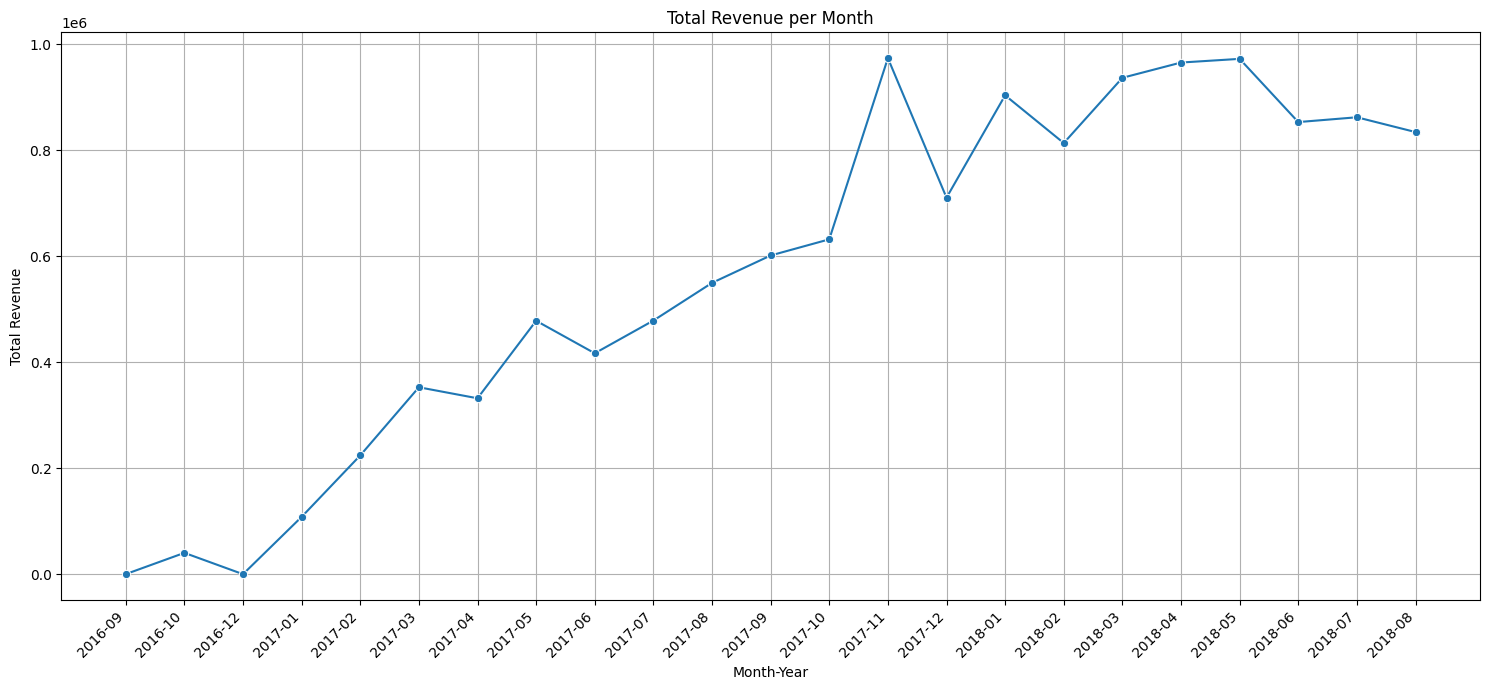

In [113]:
# Plot untuk Total Revenue per Month
plt.figure(figsize=(15, 7))
ax1 = sns.lineplot(x='month_year', y='total_revenue', data=monthly_sales, marker='o')
plt.title('Total Revenue per Month')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.tight_layout()
plt.show()

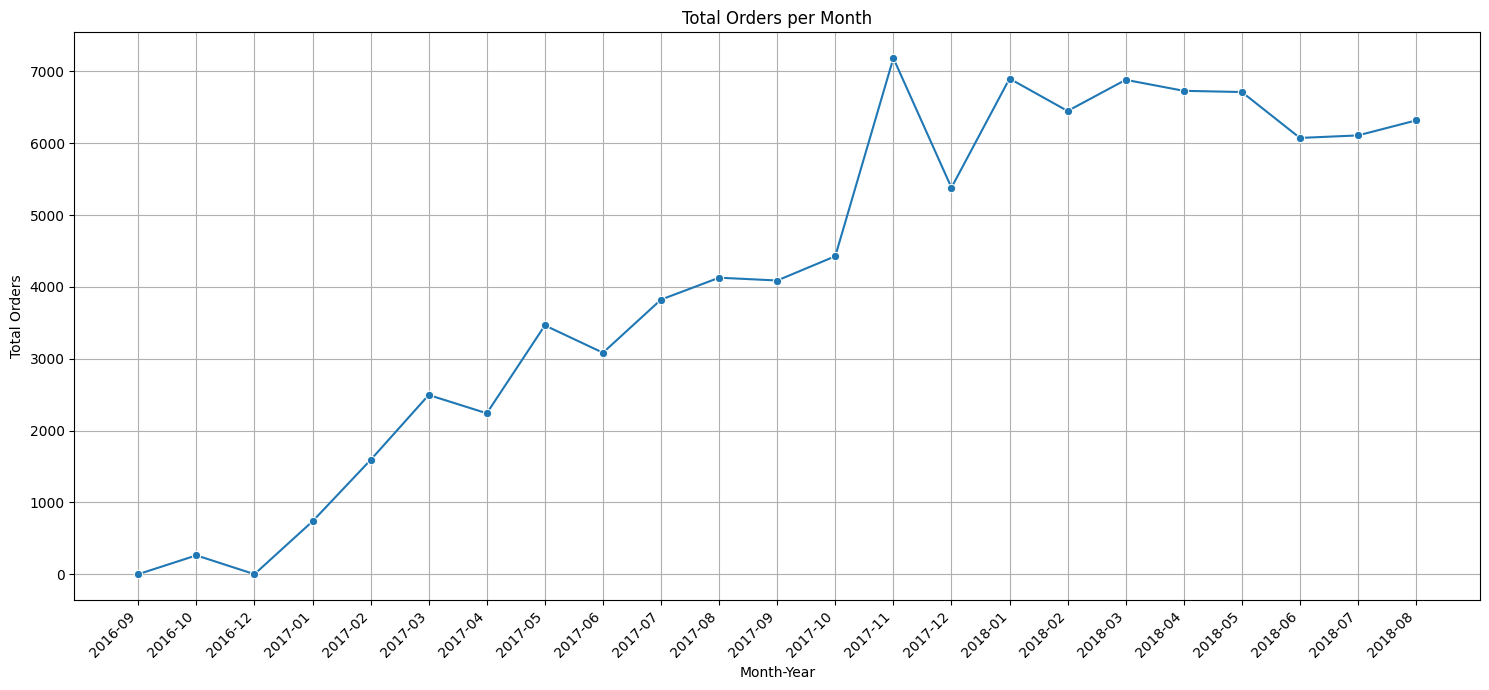

In [114]:
# Plot untuk Total Orders per Month
plt.figure(figsize=(15, 7))
ax2 = sns.lineplot(x='month_year', y='total_orders', data=monthly_sales, marker='o')
plt.title('Total Orders per Month')
plt.xlabel('Month-Year')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.tight_layout()
plt.show()

**Insight:**

*  Performa penjualan menunjukkan tren kenaikan yang signifikan diikuti dengan performa penjualan yang memiliki pola hampir mirip hal ini menunjukkan pertumbuhan secara keseluruhan.

* Pendapatan bulanan tertinggi terjadi pada November 2017, mencapai 973.861.52 dengan 7186 pesanan.

* Pendapatan Tahunan tertinggi terjadi pada tahun 2018, mencapai mencapai 7141857.68 dengan 52184 pesanan.

### Pertanyaan 2: Bagaimana demografi customer yang dimiliki?

In [115]:
# Menghitung jumlah pelanggan unik per kota
customer_count_by_city = all_df.groupby('customer_city')['customer_unique_id'].nunique().sort_values(ascending=False).head(10)

# Menghitung jumlah pelanggan unik per negara bagian
customer_count_by_state = all_df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False).head(10)

print("Top 10 Customer Cities:")
display(customer_count_by_city)

print("Top 10 Customer States:")
display(customer_count_by_state)

Top 10 Customer Cities:


,customer_unique_id
customer_city,
sao paulo,14308
rio de janeiro,6259
belo horizonte,2561
brasilia,1985
curitiba,1419
campinas,1349
porto alegre,1272
salvador,1137
guarulhos,1095


Top 10 Customer States:


,customer_unique_id
customer_state,
SP,38632
RJ,11741
MG,10842
RS,5089
PR,4703
SC,3397
BA,3119
DF,1990
ES,1912


/tmp/ipykernel_1131/1031501934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1131/1031501934.py:6: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1131/1031501934.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1131/1031501934.py:19: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(


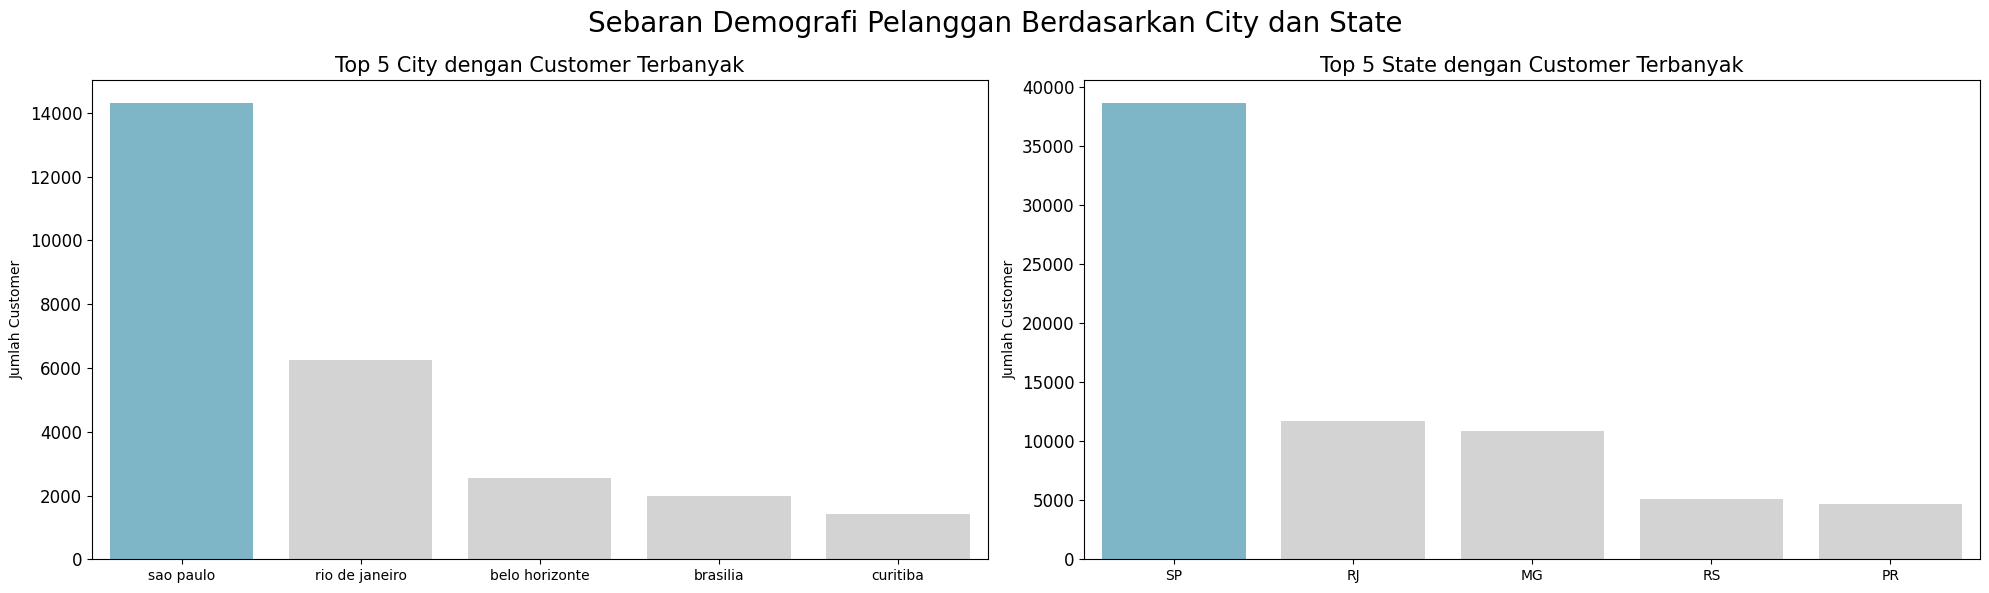

In [116]:
plt.figure(figsize=(20, 6))

# Menampilkan top 10 city
plt.subplot(1, 2, 1)
colors_city = ["#72BCD4"] + ["#D3D3D3"] * 9
sns.barplot(
    x=customer_count_by_city.head(5).index,
    y=customer_count_by_city.head(5).values,
    palette=colors_city
)
plt.title("Top 5 City dengan Customer Terbanyak", loc="center", fontsize=15)
plt.ylabel("Jumlah Customer")
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)

# Menampilkan top 10 State
plt.subplot(1, 2, 2)
colors_state = ["#72BCD4"] + ["#D3D3D3"] * 9
sns.barplot(
    x=customer_count_by_state.head(5).index,
    y=customer_count_by_state.head(5).values,
    palette=colors_state
)
plt.title("Top 5 State dengan Customer Terbanyak", loc="center", fontsize=15)
plt.ylabel("Jumlah Customer")
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)

plt.suptitle("Sebaran Demografi Pelanggan Berdasarkan City dan State", fontsize=20)
plt.tight_layout()
plt.show()

**Insight**
- kota Sao Paulo memiliki jumlah customer terbanyak secara signifikan dengan 14.308 customer, diikuti oleh Rio de Janeiro dan Belo Horizonte.

- Negara bagian SP memiliki jumlah customer terbanyak secara signifikan dengan 38632 customer, diikuti oleh RJ dan MG.

### Pertanyaan 3: Kategori produk apa yang paling banyak diminati?

In [117]:
# Menghitung jumlah pesanan untuk setiap kategori produk
all_product_popularity = all_df.groupby('product_category_name_english')['order_item_id'].count().sort_values(ascending=False)

# Menampilkan 10 kategori produk tertinggi
print("10 Kategori Product terlaris:")
display(all_product_popularity.head(10))

# Menampilkan 10 Kategori terendah
print("10 Kategori Product terendah:")
display(all_product_popularity.tail(10))

10 Kategori Product terlaris:


,order_item_id
product_category_name_english,
bed_bath_table,10952
health_beauty,9465
sports_leisure,8428
furniture_decor,8156
computers_accessories,7643
housewares,6795
watches_gifts,5857
telephony,4428
garden_tools,4267


10 Kategori Product terendah:


,order_item_id
product_category_name_english,
furniture_mattress_and_upholstery,37
diapers_and_hygiene,37
flowers,33
home_comfort_2,30
fashion_sport,29
arts_and_craftmanship,24
la_cuisine,14
cds_dvds_musicals,14
fashion_childrens_clothes,7


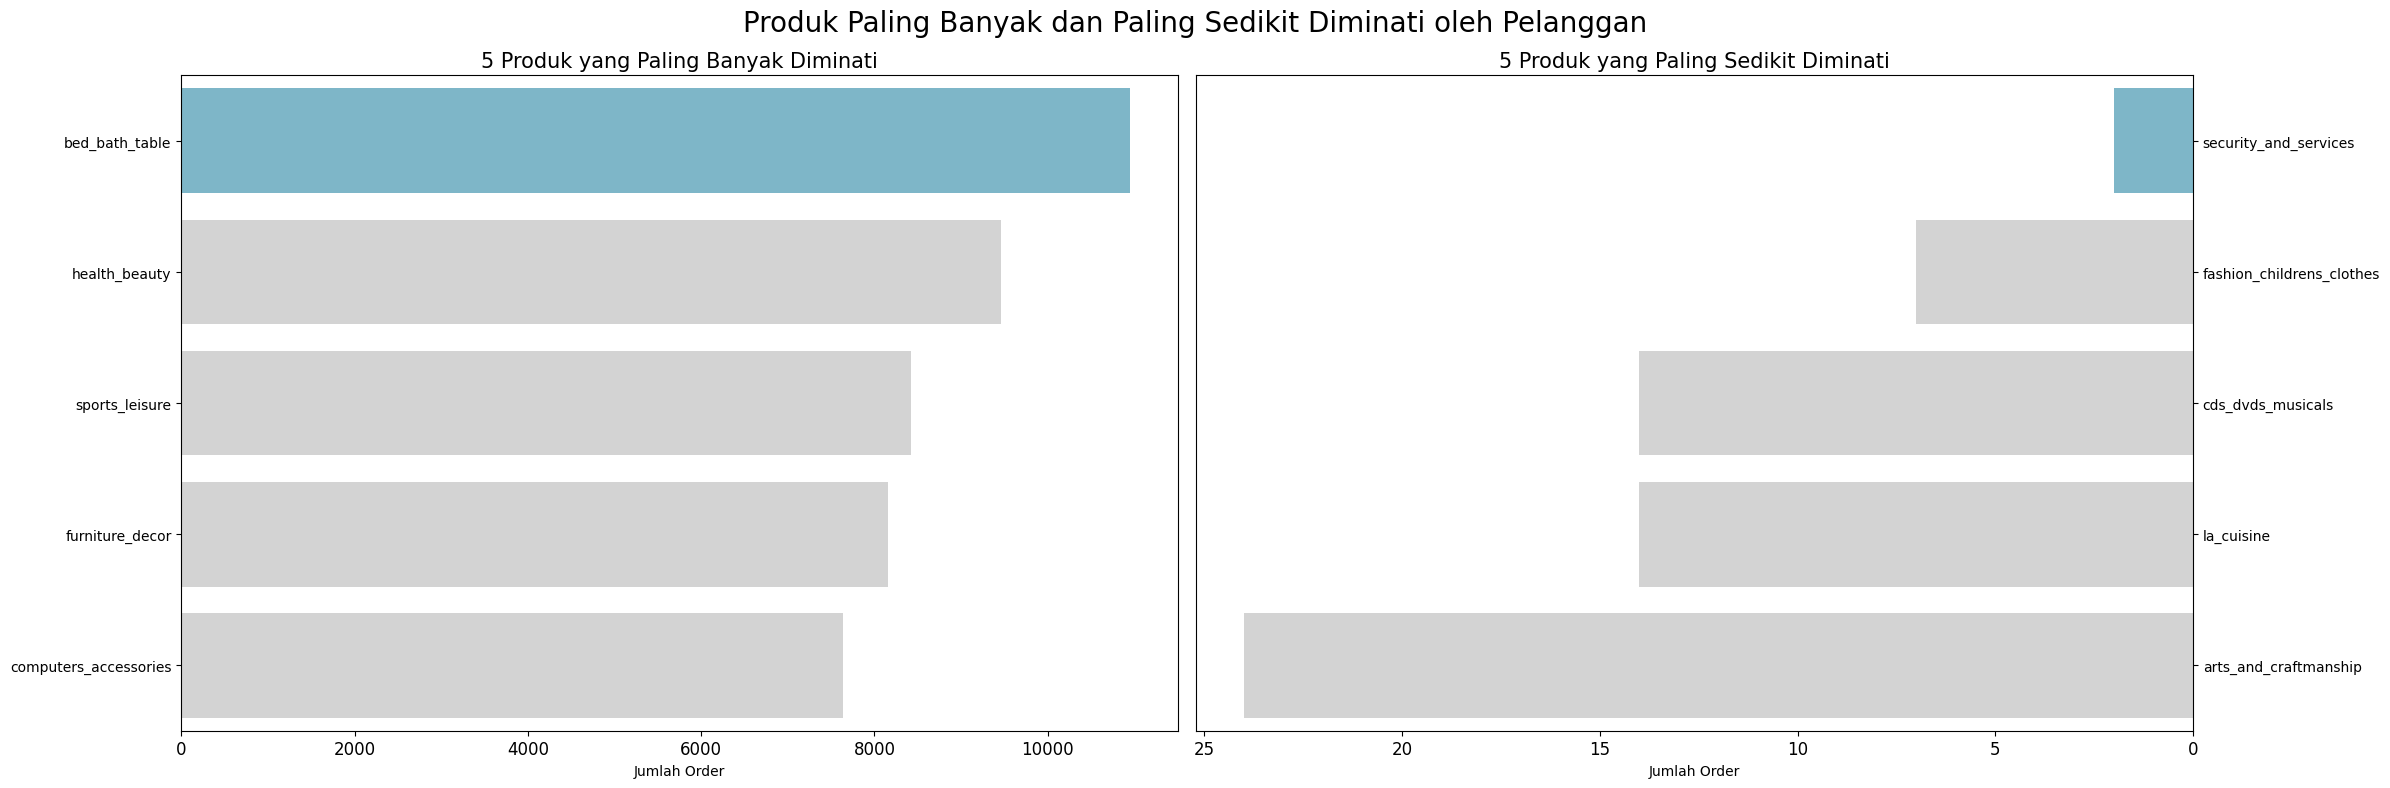

In [118]:
# Menampilkan 5 produk dengan banyak peminat dan 5 produk dengan sedikit peminat dalam bentuk bar plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24,8))

colors = ["#72BCD4"] + ["#D3D3D3"] * 4

sns.barplot(x=all_product_popularity.head(5).values, y= all_product_popularity.head(5).index, palette=colors, ax=ax[0], hue=all_product_popularity.head(5).index, legend=False)
ax[0].set_xlabel("Jumlah Order")
ax[0].set_ylabel(None)
ax[0].set_title("5 Produk yang Paling Banyak Diminati", loc="center", fontsize=15)
ax[0].tick_params(axis = 'x', labelsize=12)

least_popular_products = all_product_popularity.tail(5).sort_values(ascending=True)
sns.barplot(x=least_popular_products.values, y=least_popular_products.index, palette=colors, ax=ax[1], hue=least_popular_products.index, legend=False)
ax[1].set_xlabel("Jumlah Order")
ax[1].set_ylabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("5 Produk yang Paling Sedikit Diminati", loc="center", fontsize=15)
ax[1].tick_params(axis='x', labelsize=12)

plt.suptitle("Produk Paling Banyak dan Paling Sedikit Diminati oleh Pelanggan", fontsize=20)
plt.tight_layout()
plt.show()

**Insight:**

* Kategori produk yang paling banyak diminati adalah 'bed_bath_table' dengan 10.952 pesanan, diikuti oleh 'health_beauty' dan 'sports_leisure'.
* Kategori 'security_and_services', 'fashion_childrens_clothes', 'cds_dvds_musicals' merupakan kategori dengan jumlah pesanan paling sedikit.

## Analisis Lanjutan (Opsional)

In [119]:
# Menentukan tanggal terbaru dalam dataset dan tambahkan satu hari untuk perhitungan recency
recent_date = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Hitung nilai RFM untuk setiap customer
rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

# Ganti nama kolom agar lebih deskriptif
rfm_df.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'price': 'monetary'
}, inplace=True)


rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


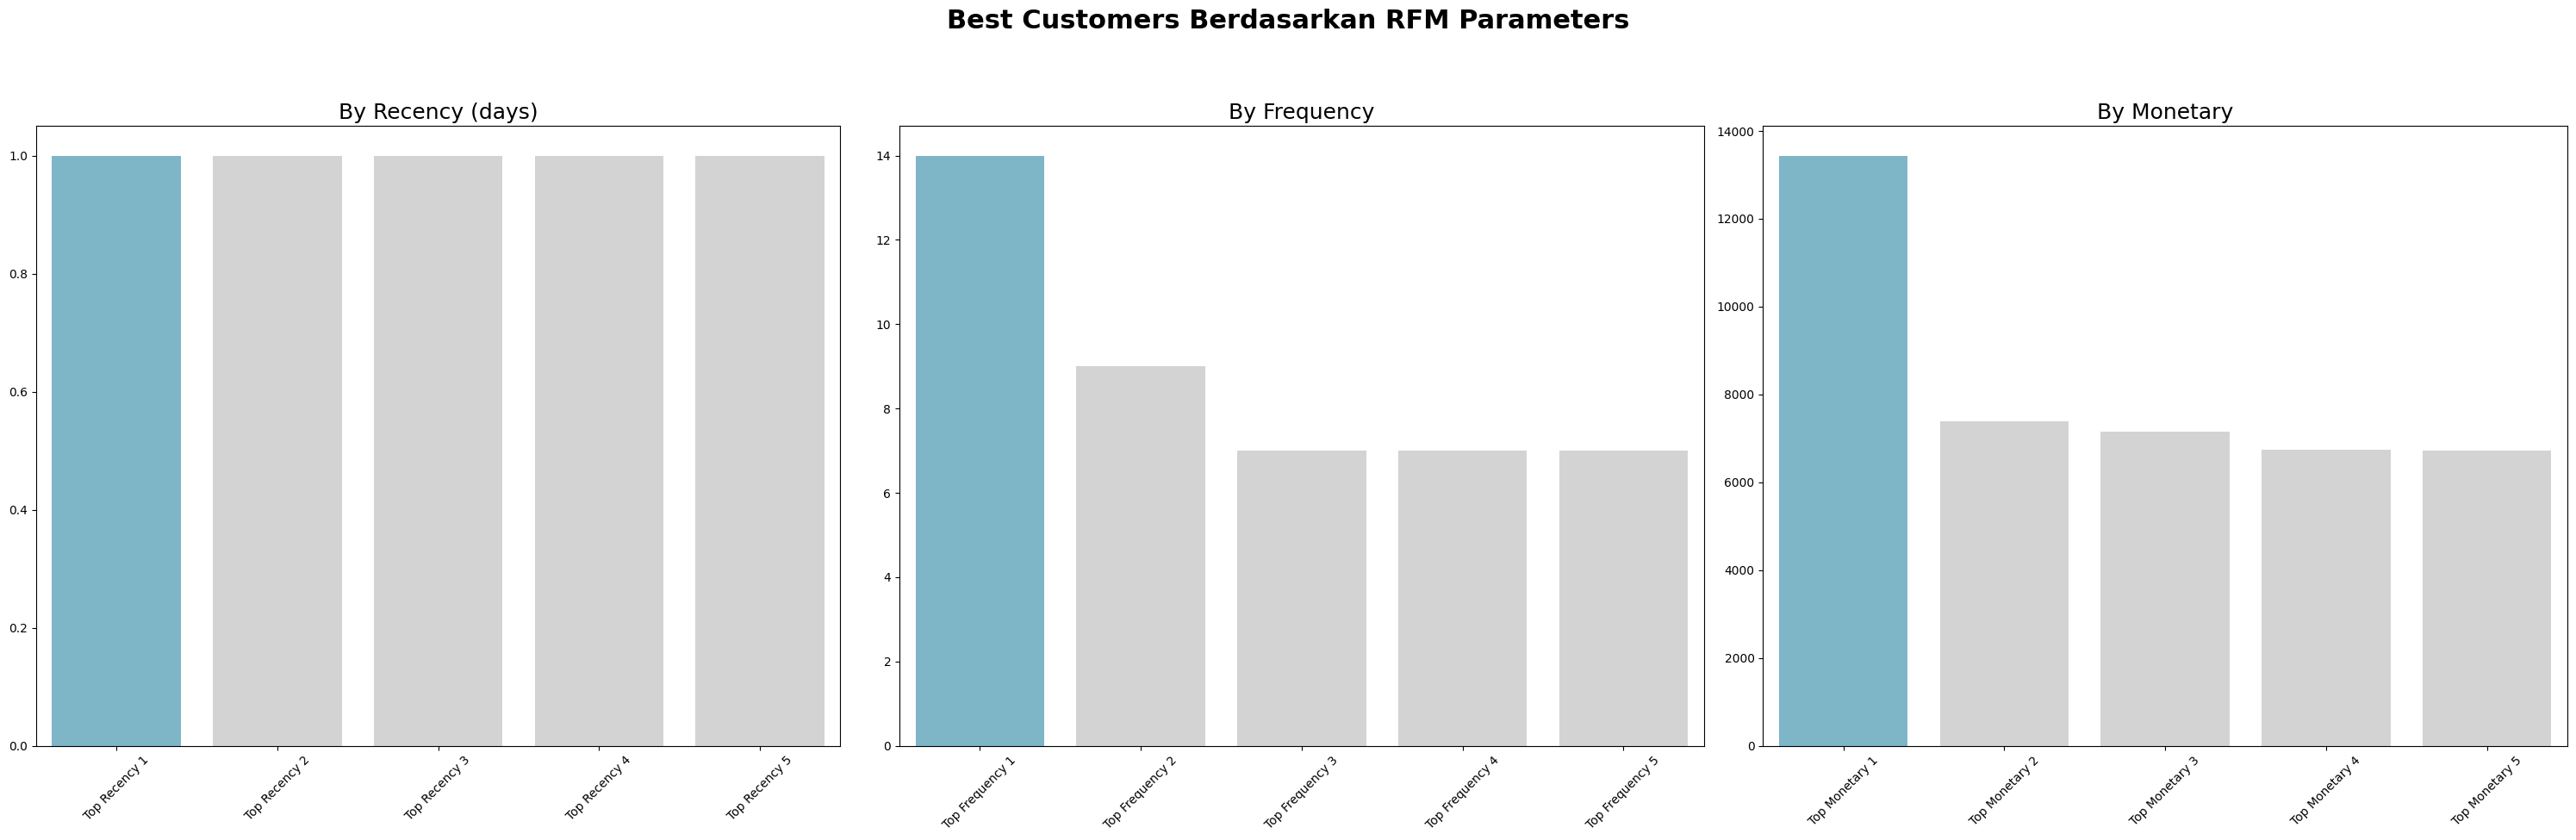

In [120]:
# Ambil 5 customer teratas berdasarkan Recency, Frequency, Monetary
top_recency = rfm_df.sort_values(by="recency", ascending=True).head(5).copy()
top_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5).copy()
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5).copy()

# Buat label untuk visualisasi supaya lebih deskriptif
top_recency['label'] = [f'Top Recency {i}' for i in range(1, 6)]
top_frequency['label'] = [f'Top Frequency {i}' for i in range(1, 6)]
top_monetary['label'] = [f'Top Monetary {i}' for i in range(1, 6)]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

colors = ["#72BCD4"] + ["#D3D3D3"] * 4

# Plot untuk Recency
sns.barplot(y="recency", x="label", data=top_recency.sort_values(by="recency", ascending=True).head(), palette=colors, ax=ax[0], hue="customer_unique_id", legend=False)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=10, rotation=45)

# Plot untuk Frequency
sns.barplot(y="frequency", x="label", data=top_frequency.sort_values(by="frequency", ascending=False).head(), palette=colors, ax=ax[1], hue="customer_unique_id", legend=False)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=10, rotation=45)

# Plot untuk Monetary
sns.barplot(y="monetary", x="label", data=top_monetary.sort_values(by="monetary", ascending=False).head(), palette=colors, ax=ax[2], hue="customer_unique_id", legend=False)
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=10, rotation=45)

plt.suptitle("Best Customers Berdasarkan RFM Parameters", fontsize=22, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:**
* Recency: Menunjukkan Top 5 pelanggan terbaru melakukan pembelian pada 1 hari yang lalu.
* Frequency: pelanggan teratas melakukan 14 pesanan.
* Monetary: Pelanggan dengan pengeluaran tertinggi mencapai 13.440.



## Conclusion & Recommendation

### Conclusion

- **Conclution pertanyaan 1: Performa penjualan dan revenue perusahaan pada pertengahan 2016 hingga pertengahan 2018**

  Perusahaan mengalami pertumbuhan penjualan dan pendapatan yang kuat secara keseluruhan dari pertengahan 2016 hingga pertengahan 2018. Meskipun ada pola bulanan yang cenderung berulang, tren jangka panjang menunjukkan peningkatan yang signifikan dari tahun ke tahun, dengan puncak penjualan bulanan yang menonjol pada November 2017 dan pencapaian pendapatan tahunan tertinggi di tahun 2018. Untuk mempertahankan momentum ini, disarankan untuk menganalisis faktor-faktor pendorong di balik puncak penjualan November 2017 dan menerapkan strategi serupa pada periode mendatang, serta terus memonitor tren untuk mengidentifikasi peluang pertumbuhan di tahun-tahun berikutnya.

- **Conclution pertanyaan 2: Demografi customer yang dimiliki**

  Demografi pelanggan menunjukkan konsentrasi yang signifikan di kota-kota besar dan negara bagian tertentu. Kota Sao Paulo menjadi pusat dengan jumlah pelanggan terbanyak (14.308 customer), diikuti oleh Rio de Janeiro dan Belo Horizonte. Secara geografis, negara bagian SP mendominasi dengan 38.632 pelanggan, diikuti oleh RJ dan MG. Hal ini mengindikasikan bahwa fokus pemasaran dan operasional dapat lebih diintensifkan pada wilayah-wilayah dengan kepadatan pelanggan tinggi untuk memaksimalkan efisiensi dan jangkauan.

- **Conclution pertanyaan 3: Kategori produk apa paling banyak diminati**

  Kategori produk 'bed_bath_table' (10.952 pesanan), 'health_beauty', dan 'sports_leisure' adalah yang paling diminati, menunjukkan permintaan tinggi untuk produk rumah tangga, perawatan pribadi, dan aktivitas fisik. Sementara itu, kategori seperti 'security_and_services', 'fashion_childrens_clothes', dan 'cds_dvds_musicals' memiliki minat yang sangat rendah. Disarankan untuk fokus pada pengembangan dan promosi kategori produk terlaris, serta mempertimbangkan strategi untuk menghidupkan kembali atau mengoptimalkan stok untuk kategori yang kurang diminati.

### Recommendation

1.  Alokasikan sumber daya pemasaran dan operasional secara lebih intensif ke kota-kota dan negara bagian dengan konsentrasi pelanggan tinggi (misalnya, Sao Paulo, Rio de Janeiro, dan negara bagian SP, RJ, MG) untuk memaksimalkan efisiensi kampanye dan penetrasi pasar.

2. Tingkatkan investasi dalam pengembangan produk dan promosi untuk kategori-kategori yang sangat diminati seperti 'bed_bath_table', 'health_beauty', dan 'sports_leisure'. Sementara itu, evaluasi ulang atau pertimbangkan strategi divestasi untuk kategori dengan permintaan rendah seperti 'security_and_services', 'fashion_childrens_clothes', 'cds_dvds_musicals'.

In [121]:
all_df.to_csv("all_data_ecommerce.csv", index=False)